## 4.2 Widget Sales

**(a)**

In [ ]:
for idx in shuffled_indices:
    s_t = int(log["s"][idx])
    a_t = int(log["a"][idx])
    r_t = log["r"][idx]
    s_next = int(log["s"][idx + 1])

    a_idx = np.searchsorted(A, a_t)
    Q[s_t, a_idx] += α * (r_t + γ * np.max(Q[s_next]) - Q[s_t, a_idx])

**(b)**

In [ ]:
Q_vi_new = np.zeros_like(Q_vi)
for i, s in enumerate(S):
    for j, a in enumerate(A):
        Q_vi_new[i, j] = sum(
            P[l] * (reward(s, a, d) + γ * np.max(Q_vi[transition(s, a, d)]))
            for l, d in enumerate(D)
        )
Q_vi_prev = Q_vi.copy()
Q_vi[:] = Q_vi_new

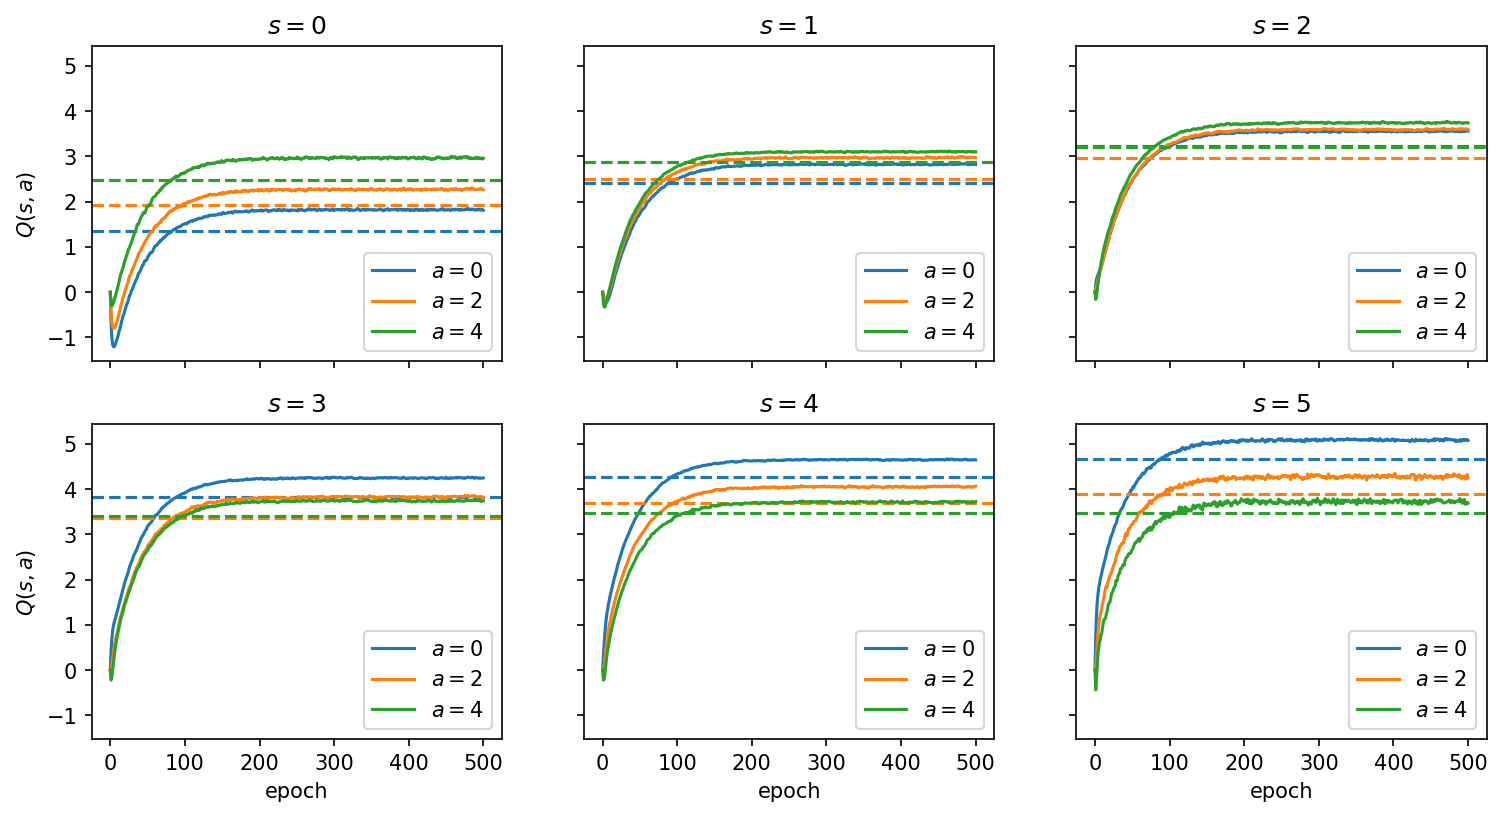

In [1]:
from IPython.display import display, Image
display(Image(filename="../widget_sales_qvalues.png"))

The Q-learning values (solid lines) converge toward the value iteration values (dashed lines) but do not match them exactly. For states $s=0, 1, 4, 5$ the action ranking is the same between both methods, so the optimal action does not change. However, at $s=2$ the ranking differs: Q-learning ranks $a=4 > a=2 > a=0$ while value iteration gives $a=0 > a=4 > a=2$, leading to a different optimal action ($a=4$ vs $a=0$). At $s=3$ the best action agrees ($a=0$) but the ordering of the suboptimal actions is swapped. These differences arise because Q-learning learns from real transitions while value iteration relies on the intern's approximate model of the dynamics and demand distribution.

**(c)**

In [ ]:
a_opt_ql = A[np.argmax(Q, axis=1)]
a_opt_vi = A[np.argmax(Q_vi, axis=1)]

_, _, r_ql = simulate(rng, lambda s: a_opt_ql[int(s)], T)
profit_ql = np.cumsum(r_ql)

_, _, r_vi = simulate(rng, lambda s: a_opt_vi[int(s)], T)
profit_vi = np.cumsum(r_vi)

Optimal policy (Q-learning): $[4, 4, 4, 0, 0, 0]$

Optimal policy (value iteration): $[4, 4, 0, 0, 0, 0]$

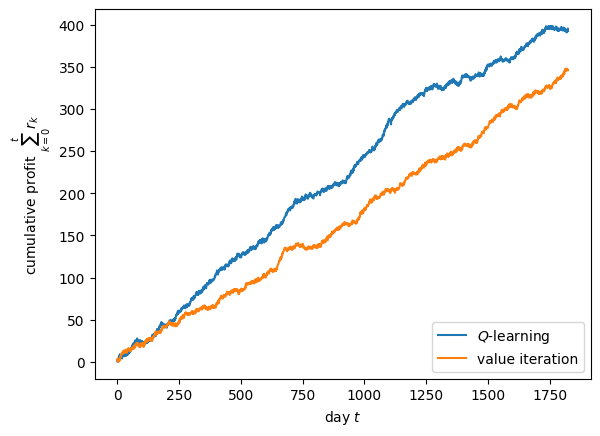

In [2]:
display(Image(filename="../widget_sales_profits.png"))

The Q-learning policy accumulates higher profit than the value iteration policy over 5 years. The two policies differ only at $s=2$: Q-learning orders 4 widgets while value iteration orders 0. Since the intern's model is only an approximation of the true dynamics and demand distribution, value iteration is optimal with respect to that approximate model but not necessarily with respect to reality. Q-learning, on the other hand, learned directly from real historical transitions, so it may have captured the true underlying dynamics more accurately. The higher cumulative profit of Q-learning suggests that the model errors in the intern's approximation hurt the value iteration policy, particularly at $s=2$ where the two methods disagree.

We also note that the simulation plots the undiscounted cumulative reward, whereas both Q-learning and value iteration were trained with a discount factor $\gamma < 1$, optimizing the discounted sum of rewards. Evaluating on the discounted sum instead, value iteration achieves a higher discounted return, which is consistent with value iteration being optimal under the discounted criterion when the transition model is precise. This suggests that the model-based approach may indeed perform better under its own training objective, and that the advantage of Q-learning observed here is specific to the undiscounted evaluation.